# Sorting, Filtering, and Counting Categories

In this module, you will learn how to:
* Count how many items belong to each category using Pandas `.value_counts()`.
* Filter data using conditions.
* Generate a horizontal bar chart to compare the categories.

**Why it matters:** In software development and business, you often need to answer questions like: *"Which feature is used the most?"* or *"How many users are from the UK?"*. Categorical counting and horizontal bar charts are the perfect tools to answer these questions.

### 2. Simple Explanation with an Everyday Analogy
Imagine you have a large bucket of colorful candy:
* **Counting**: Sorting the candy by color (Red, Blue, Green) and counting how many you have of each.
* **Filtering**: Only keeping the Red ones because you love strawberry flavor.
* **Plotting**: Drawing a chart where each bar represents a candy color, and the length of the bar shows the count.

### Code Examples

Let's perform a categorical analysis of the Pokémon types and plot them.

#### Counting Categories with `.value_counts()`
Let's see how many Pokémon belong to each primary type (Type 1).




> **Important:** every notebook has its own **kernel** (the Python process that runs the cells).
> A kernel does not remember variables from another notebook. `df_clean` was made in notebook 30,
> so this notebook must build its own copy of the data before using it.


In [4]:
# pandas is the library for tables of data (rows and columns), like a spreadsheet.
# matplotlib is the library we use to draw charts.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Build the same small table we used in notebook 30, so this notebook can run on its own.
df = pd.DataFrame({
    'Name': ['Bulbasaur', 'Ivysaur', 'Venusaur', 'Charmander', 'Charmeleon',
             'Charizard', 'Squirtle', 'Wartortle', 'Blastoise', 'Caterpie'],
    'Type 1': ['Grass', 'Grass', 'Grass', 'Fire', 'Fire',
               'Fire', 'Water', 'Water', 'Water', 'Bug'],
    'Type 2': ['Poison', 'Poison', 'Poison', np.nan, np.nan,
               'Flying', np.nan, np.nan, np.nan, np.nan],
    'HP': [45, 60, 80, 39, 58, 78, 44, 59, 79, 45],
    'Attack': [49, 62, 82, 52, 64, 84, 48, 63, 83, 30],
})

# Same cleaning step as notebook 30: NaN means "missing value".
# .copy() makes a separate table so we do not change the original one.
df_clean = df.copy()
# .fillna('None') replaces every missing value with the text 'None'.
df_clean['Type 2'] = df_clean['Type 2'].fillna('None')

df_clean

,Name,Type 1,Type 2,HP,Attack
0,Bulbasaur,Grass,Poison,45,49
1,Ivysaur,Grass,Poison,60,62
2,Venusaur,Grass,Poison,80,82
3,Charmander,Fire,None,39,52
4,Charmeleon,Fire,None,58,64
5,Charizard,Fire,Flying,78,84
6,Squirtle,Water,None,44,48
7,Wartortle,Water,None,59,63
8,Blastoise,Water,None,79,83
9,Caterpie,Bug,None,45,30


In [5]:
# .value_counts() counts how many rows have each different value in a column.
# It returns the categories sorted from the most common to the least common.
type_counts = df_clean['Type 1'].value_counts()
print(type_counts)

Type 1
Grass    3
Fire     3
Water    3
Bug      1
Name: count, dtype: int64


#### B) Creating a Horizontal Bar Chart for Category Counts
Let's visualize this using a horizontal bar chart (`plt.barh()`) so it is easy to read.


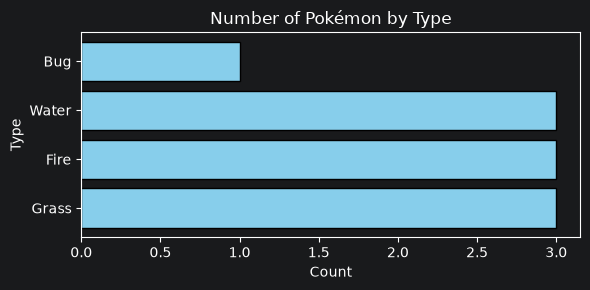

In [6]:
plt.figure(figsize=(6, 3))

# Plot horizontal bars
plt.barh(type_counts.index, type_counts.values, color='skyblue', edgecolor='black')

plt.title("Number of Pokémon by Type")
plt.xlabel("Count")
plt.ylabel("Type")
plt.tight_layout()
plt.show()

### Common Mistakes Beginners Make
1. **Using `plt.bar()` instead of `plt.barh()` for Long Labels**: If you have many categories with long text names, vertical bars (`plt.bar()`) will overlap and become unreadable on the X-axis. Always use horizontal bars (`plt.barh()`) for text categories.
2. **Forgetting `.values`**: In Pandas, `.value_counts()` returns a Series. The categories are in `.index`, and the numbers are in `.values`. Make sure to pass both to your plot!


#### Exercise 1 (Easy)
Write a Python script to filter our DataFrame and keep only the Pokémon whose **HP** is greater than or equal to 60.


In [7]:
# Filter rows where HP >= 60
high_hp_pokemon = df_clean[df_clean['HP'] >= 60]
print(high_hp_pokemon[['Name', 'HP']])

        Name  HP
1    Ivysaur  60
2   Venusaur  80
5  Charizard  78
8  Blastoise  79


#### Exercise 2 (Medium)
From the filtered list in Exercise 1, find the average **Attack** score.

In [8]:
# Calculate average Attack of high HP Pokémon
avg_attack = high_hp_pokemon['Attack'].mean()
print(f"Average Attack of High HP Pokémon: {avg_attack:.1f}")

Average Attack of High HP Pokémon: 77.8
